
![image.png](img/save/11.png)


In [64]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [59]:
img = cv.imread('img/balls.tif')
gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

In [74]:
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (50, 50))
deletesmall = cv.morphologyEx(gray, cv.MORPH_CLOSE, kernel)

_, deletesmall2 = cv.threshold(deletesmall, 100, 255, cv.THRESH_BINARY)


In [79]:
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (120, 120))
segment = cv.morphologyEx(deletesmall, cv.MORPH_OPEN, kernel)

In [ ]:
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
line = cv.morphologyEx(segment, cv.MORPH_GRADIENT, kernel)
_, mask = cv.threshold(line, 0, 255, cv.THRESH_BINARY)

# 원본 복사
result = img.copy()
result[mask == 255] = [255, 255, 255]  


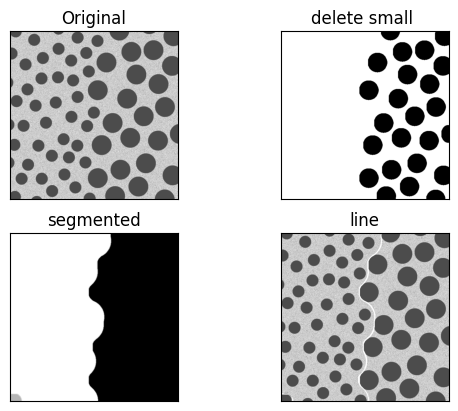

In [91]:

titles = ['Original', 'delete small ', 'segmented', 'line']
images = [img, deletesmall2, segment, result]
for i in range(4):
    plt.subplot(2, 2, i+1), plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.show()
